In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import ROOT as root
from ROOT import TFile, TTree, TList
from scipy.optimize import curve_fit
import sympy as sp

In [2]:
cGy = 1e2 # cGy -> Gy

In [3]:
dataset="DetRotX90deg/20241012_063241"

In [4]:
filenames = [4, 6, 8, 10, 15, 20, 25, 30, 35]
mean_dose = []
mean_dose1 = []
mean_dose2 = []
dose_grid = []

df10x10 = pd.DataFrame()

for z in filenames:
     print(str(z),"cm data processing ...")
     pathList = glob.glob(dataset+"/0cm"+"/*/2Dmap"+ str(z) +"cm4mm.out")
     print(pathList)
     df10x10 = pd.DataFrame()
     
     for filename in pathList:
        temp_df = pd.read_csv(filename, sep=",", header=None, skiprows=4, 
                               names=["iX", "iY", "iZ", "dose", "dose^2", "entries"])
        df10x10 = df10x10.add(temp_df, fill_value=0)
        
     if not df10x10.empty:
        df10x10 /= len(pathList)
        dose_pivot = df10x10.pivot(index='iX', columns='iZ', values='dose') * cGy

        dose_grid.append(dose_pivot)
        mean_dose1.append(np.mean(dose_pivot,1))
        mean_dose2.append(np.mean(dose_pivot,0))


4 cm data processing ...
['DetRotX90deg/20241012_063241/0cm/9/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/11/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/7/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/6/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/1/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/10/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/8/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/4/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/3/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/12/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/2/2Dmap4cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/5/2Dmap4cm4mm.out']
6 cm data processing ...
['DetRotX90deg/20241012_063241/0cm/9/2Dmap6cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/11/2Dmap6cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/7/2Dmap6cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/6/2Dmap6cm4mm.out', 'DetRotX90deg/20241012_063241/0cm/1/2Dmap6cm4mm.out', 'DetRotX90deg/20241012_063

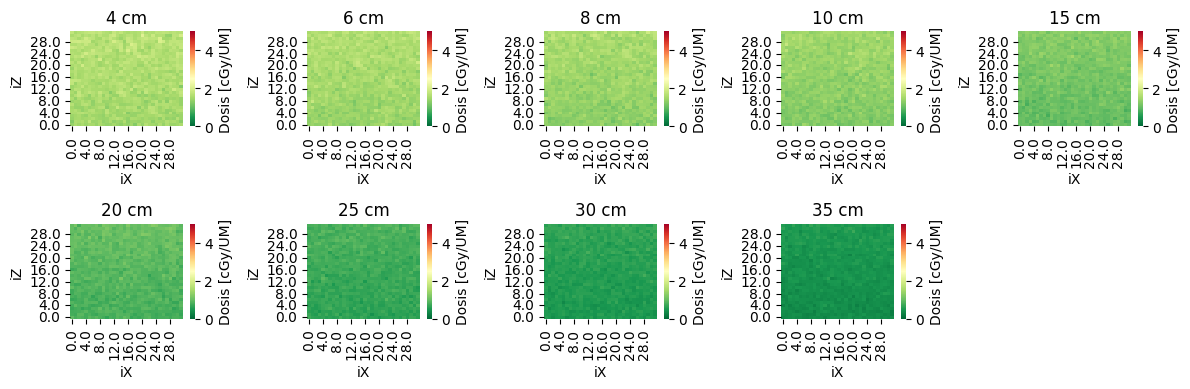

In [5]:
fig=plt.figure(figsize=(12,4))

i = 0
for data in dose_grid:
    ax1=fig.add_subplot(2,5,i+1)
    ax1.set_title(str(filenames[i]) + ' cm')
    cbar_kws = { 'label': 'Dosis [cGy/UM]'}
    ax1 = sns.heatmap(data=data.T, cmap='RdYlGn_r', cbar=True, cbar_kws=cbar_kws, vmin=0, vmax=5)
    ax1.invert_yaxis()
    i=i+1

fig.tight_layout()
plt.show()

In [6]:
nC = 1e9  # nC -> C
nofEvents = 1000e6 
nofEvents = 50e6    
fScaleFactorMU = 1/2.3514811546434146e-13
fSimulatedMU = 1
scale_factor = (1./nofEvents)*fScaleFactorMU*fSimulatedMU

In [7]:
print(scale_factor) # 4252.64

85052.77603652689


In [8]:
SensorReadout1 = np.zeros([32,12,np.size(filenames)])
SensorReadout2 = np.zeros([32,12,np.size(filenames)])
mean_charge1 = []
mean_charge2 = []

k=0
for z in filenames:
     print(str(z),"cm data processing ...")
     pathList = glob.glob(dataset+"/"+ str(z) +"cm"+"/*/BB7Readout.root")
     print(pathList)

     j=0
     for path in pathList:
          print("File",str(j),"is being read ...")
          f = root.TFile(path)
          myTree = f.Get("BB7Hits")
          entries = myTree.GetEntriesFast()

          for entry in myTree:
               stripID = int(entry.StripID)
               if(entry.SensorID==0):
                    SensorReadout1[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
               if(entry.SensorID==1):
                    SensorReadout2[stripID,j,k] += myTree.GetLeaf('Charge[coulomb]').GetValue()*scale_factor*nC
          j=j+1
     mean_charge1.append(np.mean(SensorReadout1[:,:,k],1))
     mean_charge2.append(np.mean(SensorReadout2[:,:,k],1))
     k=k+1

4 cm data processing ...
['DetRotX90deg/20241012_063241/4cm/9/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/11/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/7/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/6/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/1/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/10/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/8/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/4/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/3/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/12/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/2/BB7Readout.root', 'DetRotX90deg/20241012_063241/4cm/5/BB7Readout.root']
File 0 is being read ...
File 1 is being read ...
File 2 is being read ...
File 3 is being read ...
File 4 is being read ...
File 5 is being read ...
File 6 is being read ...
File 7 is being read ...
File 8 is being read ...
File 9 is being read ...
File 10 is being read ...
File 11 is being read ...
6 cm data processing 

In [9]:
np.shape(mean_charge2)

(9, 32)

In [10]:
#mean_charge2=np.flip(mean_charge2,1)

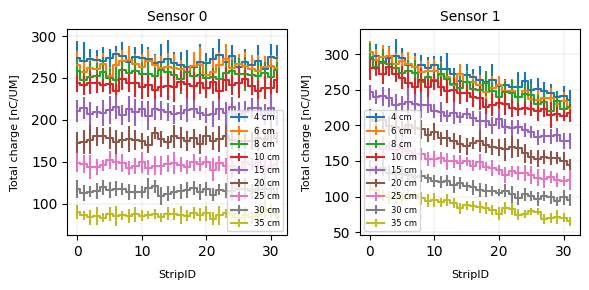

In [11]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(121)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax1.errorbar(x,np.mean(SensorReadout1[:,:,k],1),yerr=np.std(SensorReadout1[:,:,k],1), ds='steps-mid', label=str(z) + ' cm')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for z in filenames:
    ax2.errorbar(x,np.mean(SensorReadout2[:,:,k],1),yerr=np.std(SensorReadout2[:,:,k],1), ds='steps-mid', label=str(z) + ' cm')
    k=k+1

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()

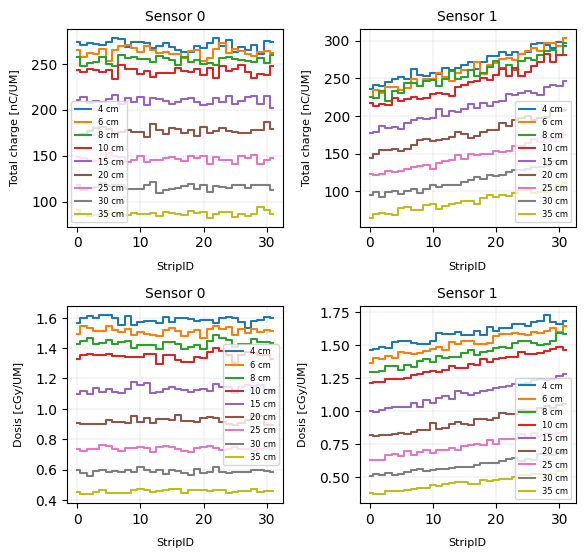

In [12]:
fig=plt.figure(figsize=(6,8))

x=np.linspace(0, 31, 32)

ax1=fig.add_subplot(321)
ax1.set_title('Sensor 0', fontsize=10)
ax1.set_xlabel('StripID', fontsize=8,labelpad=8)
ax1.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax1.set_ylim([0, 200])
ax1.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax1.errorbar(x,np.array(mean_charge1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(322)
ax2.set_title('Sensor 1', fontsize=10)
ax2.set_xlabel('StripID', fontsize=8,labelpad=8)
ax2.set_ylabel('Total charge [nC/UM]', fontsize=8,labelpad=8)
#ax2.set_ylim([0, 200])
ax2.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax2.errorbar(x,np.array(mean_charge2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax2.legend(loc='best', fontsize="6")

ax3=fig.add_subplot(323)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax3.set_ylim([0, 200])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(324)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('Dosis [cGy/UM]', fontsize=8,labelpad=8)
#ax4.set_ylim([0, 200])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()

In [13]:
charge1 = np.array(mean_charge1) # nC
print("Carga promedio por strip (Sensor1):",charge1,"nC/UM")

charge2 = np.array(mean_charge2) # nC
print("Carga promedio por strip (Sensor2):",charge2,"nC/UM")

dose1 = np.array(mean_dose1) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor1):",dose1,"cGy/UM")

dose2 = np.array(mean_dose2) # cGy
print("Dosis absorbda en agua por posición de strip (Sensor2):",dose2,"cGy/UM")

Carga promedio por strip (Sensor1): [[273.53704904 270.67013374 272.22592002 271.78592942 270.6883791
  273.94025821 278.11653897 276.63246115 268.93689837 274.39381444
  273.87011458 272.47556246 267.24852294 269.30853728 272.2896249
  267.95182495 265.06564    263.12041233 262.8065324  269.48184038
  267.5948123  272.58951108 277.7358211  269.10801774 275.92240017
  263.2499286  268.43976881 265.40173981 270.78737667 261.22253152
  275.23572077 273.79512884]
 [265.30249695 257.24967623 262.22220054 260.54120638 266.4464482
  252.82988288 265.1427118  269.66306869 270.93520304 267.05586502
  262.83901226 270.03188568 264.96652546 262.33746643 263.43676327
  261.29558222 261.20925318 256.87661557 263.74898297 265.66051231
  253.23465914 256.59473175 265.83501345 272.51299798 262.05767093
  266.35150124 264.13160862 261.063003   258.68422006 262.57013309
  263.76686835 261.54768774]
 [257.81488153 247.26323801 251.39128389 252.0739581  257.7044623
  249.66185952 247.87464209 259.9060448

In [14]:
def lineal0(x, a):
    return a * x

In [15]:
def pow0(x, a, b):
    return a * x ** b

In [16]:
strips=np.linspace(0, 31, 32)

In [17]:
popt1=[]
pcov1=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge1[:,stripID], dose1[:,stripID])
        popt1.append(popt_tmp)
        pcov1.append(pcov_tmp)
        print("Optimal parameters (a):", popt1[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.00545957]
Optimal parameters (a): [0.00563229]
Optimal parameters (a): [0.00560452]
Optimal parameters (a): [0.00558056]
Optimal parameters (a): [0.00555738]
Optimal parameters (a): [0.00564787]
Optimal parameters (a): [0.00555071]
Optimal parameters (a): [0.00542741]
Optimal parameters (a): [0.00555863]
Optimal parameters (a): [0.00550047]
Optimal parameters (a): [0.00555202]
Optimal parameters (a): [0.00557904]
Optimal parameters (a): [0.00551466]
Optimal parameters (a): [0.00547649]
Optimal parameters (a): [0.0056087]
Optimal parameters (a): [0.00562243]
Optimal parameters (a): [0.00560515]
Optimal parameters (a): [0.00552232]
Optimal parameters (a): [0.00550557]
Optimal parameters (a): [0.00555741]
Optimal parameters (a): [0.00557178]
Optimal parameters (a): [0.00566876]
Optimal parameters (a): [0.00566992]
Optimal parameters (a): [0.0055675]
Optimal parameters (a): [0.00556254]
Optimal parameters (a): [0.00551582]
Optimal parameters (a): [0.00554303]
Opt

In [18]:
popt2=[]
pcov2=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(lineal0, charge2[:,stripID], dose2[:,stripID])
        popt2.append(popt_tmp)
        pcov2.append(pcov_tmp)
        print("Optimal parameters (a):", popt2[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a): [0.00579158]
Optimal parameters (a): [0.00575738]
Optimal parameters (a): [0.00571657]
Optimal parameters (a): [0.00579883]
Optimal parameters (a): [0.00571849]
Optimal parameters (a): [0.00577416]
Optimal parameters (a): [0.00570106]
Optimal parameters (a): [0.00557142]
Optimal parameters (a): [0.0056797]
Optimal parameters (a): [0.0056472]
Optimal parameters (a): [0.00564423]
Optimal parameters (a): [0.00569446]
Optimal parameters (a): [0.00565735]
Optimal parameters (a): [0.0056909]
Optimal parameters (a): [0.00563121]
Optimal parameters (a): [0.00560061]
Optimal parameters (a): [0.00552899]
Optimal parameters (a): [0.00557019]
Optimal parameters (a): [0.00555858]
Optimal parameters (a): [0.00551738]
Optimal parameters (a): [0.00548574]
Optimal parameters (a): [0.0054933]
Optimal parameters (a): [0.00550627]
Optimal parameters (a): [0.00550942]
Optimal parameters (a): [0.00550416]
Optimal parameters (a): [0.00541672]
Optimal parameters (a): [0.0054136]
Optima

In [19]:
popt3=[]
pcov3=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge1[:,stripID], dose1[:,stripID])
        popt3.append(popt_tmp)
        pcov3.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt3[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00228371 1.16050447]
Optimal parameters (a, b): [0.00158868 1.23369989]
Optimal parameters (a, b): [0.001831   1.20625333]
Optimal parameters (a, b): [0.002105   1.17980034]
Optimal parameters (a, b): [0.00221312 1.16959543]
Optimal parameters (a, b): [0.00150624 1.24393845]
Optimal parameters (a, b): [0.00199124 1.18897333]
Optimal parameters (a, b): [0.00250048 1.1424178 ]
Optimal parameters (a, b): [0.0024647  1.14967107]
Optimal parameters (a, b): [0.00350772 1.08282728]
Optimal parameters (a, b): [0.00294093 1.11713173]
Optimal parameters (a, b): [0.00348398 1.08678212]
Optimal parameters (a, b): [0.00156344 1.23260067]
Optimal parameters (a, b): [0.00344239 1.08561378]
Optimal parameters (a, b): [0.00245206 1.15252543]
Optimal parameters (a, b): [0.00221928 1.17162239]
Optimal parameters (a, b): [0.00227195 1.16678417]
Optimal parameters (a, b): [0.00212746 1.17617542]
Optimal parameters (a, b): [0.00148444 1.24197779]
Optimal parameters (a, b): [0.0

In [20]:
popt4=[]
pcov4=[]
for stripID, value in enumerate(strips):
    # Apply curve fitting
    try:
        popt_tmp, pcov_tmp = curve_fit(pow0, charge2[:,stripID], dose2[:,stripID])
        popt4.append(popt_tmp)
        pcov4.append(pcov_tmp)
        print("Optimal parameters (a, b):", popt4[-1])
    except Exception as e:
        print("An error occurred during curve fitting:", e)

Optimal parameters (a, b): [0.00291026 1.13010887]
Optimal parameters (a, b): [0.00230485 1.1727431 ]
Optimal parameters (a, b): [0.0023194  1.16981708]
Optimal parameters (a, b): [0.00248859 1.15929088]
Optimal parameters (a, b): [0.00266023 1.14349029]
Optimal parameters (a, b): [0.0023549  1.16841733]
Optimal parameters (a, b): [0.00238164 1.16334586]
Optimal parameters (a, b): [0.00292825 1.11976241]
Optimal parameters (a, b): [0.00258568 1.14698082]
Optimal parameters (a, b): [0.00219448 1.17612639]
Optimal parameters (a, b): [0.00252387 1.14977449]
Optimal parameters (a, b): [0.0021947  1.17708558]
Optimal parameters (a, b): [0.00229444 1.16749963]
Optimal parameters (a, b): [0.00229009 1.1688422 ]
Optimal parameters (a, b): [0.00197153 1.1941659 ]
Optimal parameters (a, b): [0.00216704 1.17533481]
Optimal parameters (a, b): [0.00203225 1.18422275]
Optimal parameters (a, b): [0.00246848 1.14999866]
Optimal parameters (a, b): [0.00224405 1.16704689]
Optimal parameters (a, b): [0.0

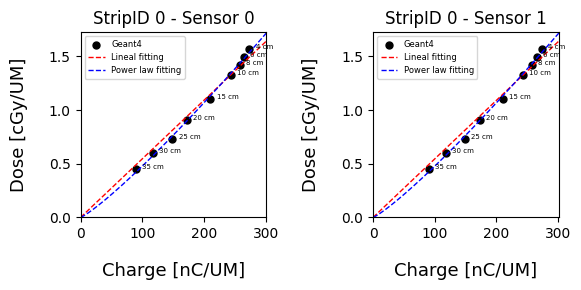

In [21]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig=plt.figure(figsize=(6,3))

ax1=fig.add_subplot(121)
ax1.set_title("StripID 0 - Sensor 0")
ax1.set_xlim([0, np.max(charge1[:,0])*1.1])
ax1.set_ylim([0, np.max(dose1[:,0])*1.1])
ax1.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax1.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax1.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax1.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax1.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax1.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax1.legend(loc='best', fontsize="6")

ax2=fig.add_subplot(122)
ax2.set_title("StripID 0 - Sensor 1")
ax2.set_xlim([0, np.max(charge1[:,0])*1.1])
ax2.set_ylim([0, np.max(dose1[:,0])*1.1])
ax2.set_xlabel('Charge [nC/UM]', fontsize=13,labelpad=15)
ax2.set_ylabel('Dose [cGy/UM]', fontsize=13,labelpad=15)
ax2.scatter(charge1[:,0],dose1[:,0],s=25, facecolors='black', edgecolors='black', label="Geant4")
for i, label in enumerate(filenames):
    ax2.annotate(str(label)+' cm', (charge1[:,0][i] + 10, dose1[:,0][i]),fontsize=5)
ax2.plot(x1, lineal0(x1, *popt1[0]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
ax2.plot(x1, pow0(x1, *popt3[0]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

ax2.legend(loc='best', fontsize="6")

fig.tight_layout()

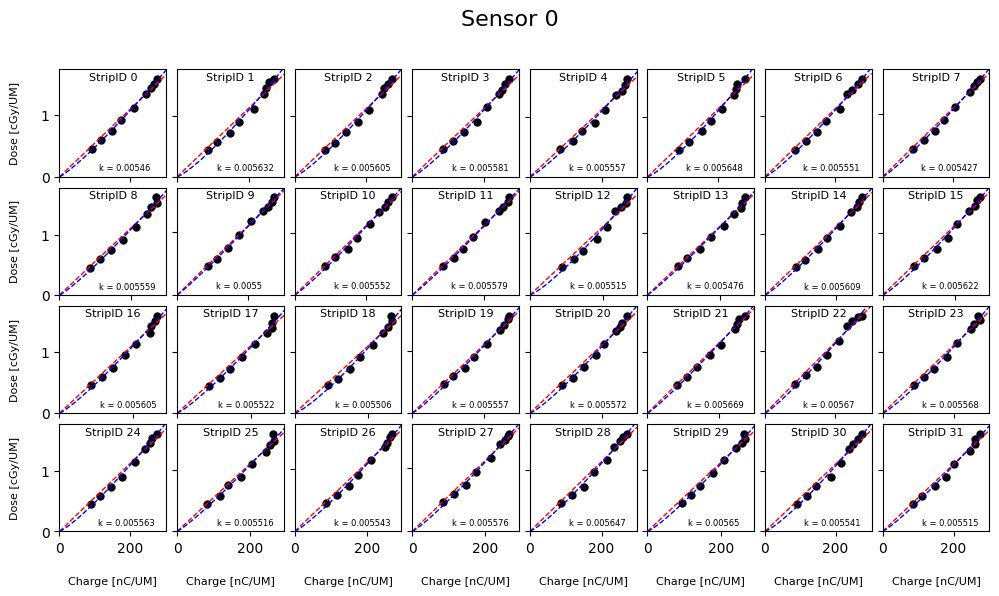

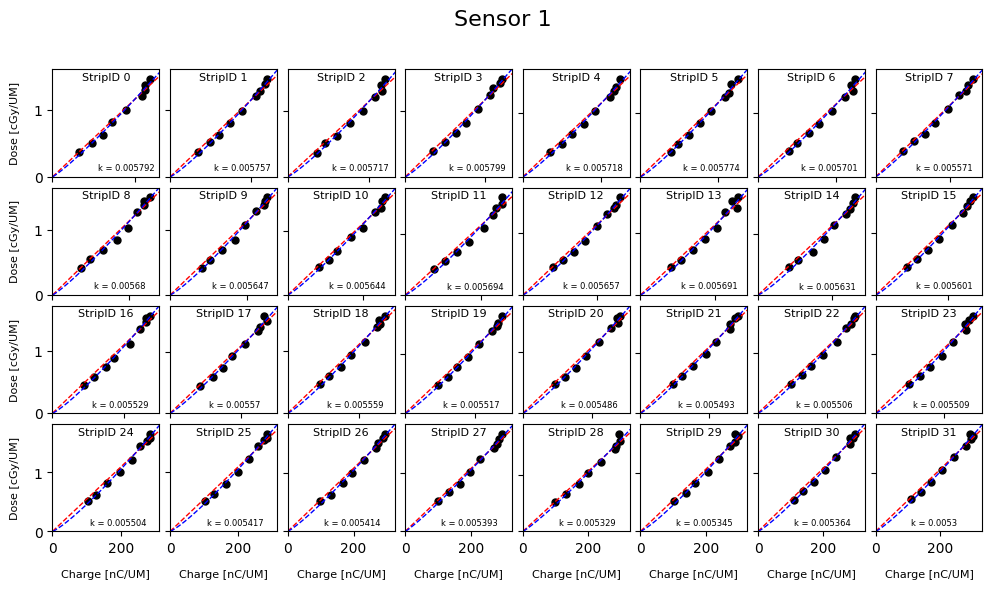

In [24]:
charge1_max=int(np.max(charge1[:])*1.1)
x1=np.linspace(0, charge1_max, charge1_max)

fig1=plt.figure(figsize=(12,6))
fig1.suptitle('Sensor 0', fontsize=16)

for stripID, value in enumerate(strips):
    ax1=fig1.add_subplot(4,8,stripID+1)
    ax1.set_xlim([0, np.max(charge1[:,stripID])*1.1])
    ax1.set_ylim([0, np.max(dose1[:,stripID])*1.1])
    ax1.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax1.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_xticklabels([])
    if(stripID%8==0):
        ax1.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=15)
    else:
        ax1.set_yticklabels([])
    ax1.scatter(charge1[:,stripID],dose1[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax1.annotate(str(label)+' cm', (charge1[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax1.annotate("k = " + str(np.round(popt1[stripID][0],6)), (110, 0.1),fontsize=6)
    ax1.plot(x1, lineal0(x1, *popt1[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax1.plot(x1, pow0(x1, *popt3[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax1.legend(loc='best', fontsize="6")

fig1.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()

charge2_max=int(np.max(charge2[:])*1.1)
x2=np.linspace(0, charge2_max, charge2_max)

fig2=plt.figure(figsize=(12,6))
fig2.suptitle('Sensor 1', fontsize=16)

for stripID, value in enumerate(strips):
    ax2=fig2.add_subplot(4,8,stripID+1)
    ax2.set_xlim([0, np.max(charge2[:,stripID])*1.1])
    ax2.set_ylim([0, np.max(dose2[:,stripID])*1.1])
    ax2.set_title('StripID '+ str(stripID), fontsize=8, y=1.0, pad=-8)
    if(stripID>=24):
        ax2.set_xlabel('Charge [nC/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_xticklabels([])
    if(stripID%8==0):
        ax2.set_ylabel('Dose [cGy/UM]', fontsize=8,labelpad=10)
    else:
        ax2.set_yticklabels([])
    ax2.scatter(charge2[:,stripID],dose2[:,stripID],s=25, facecolors='black', edgecolors='black', label="Geant4")
    #for i, label in enumerate(filenames):
    #    ax2.annotate(str(label)+' cm', (charge2[:,stripID][i] + 10, dose[i]),fontsize=5)
    ax2.annotate("k = " + str(np.round(popt2[stripID][0],6)), (110, 0.1),fontsize=6)
    ax2.plot(x2, lineal0(x2, *popt2[stripID]), linestyle="--", linewidth=1, color="red", ms=5,zorder=2,label="Lineal fitting")
    ax2.plot(x2, pow0(x2, *popt4[stripID]), linestyle="--", linewidth=1, color="blue", ms=5,zorder=2,label="Power law fitting")

#ax2.legend(loc='best', fontsize="6")

fig2.subplots_adjust(wspace=0.1, hspace=0.1) #tight_layout()


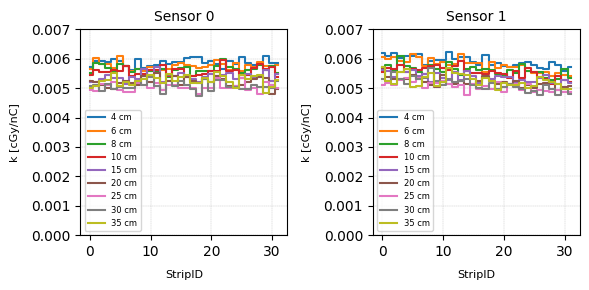

In [23]:
fig=plt.figure(figsize=(6,3))

x=np.linspace(0, 31, 32)

ax3=fig.add_subplot(121)
ax3.set_title('Sensor 0', fontsize=10)
ax3.set_xlabel('StripID', fontsize=8,labelpad=8)
ax3.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax3.set_ylim([0, 0.007])
ax3.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax3.errorbar(x,np.array(mean_dose1[i]/mean_charge1[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1


ax3.legend(loc='best', fontsize="6")

ax4=fig.add_subplot(122)
ax4.set_title('Sensor 1', fontsize=10)
ax4.set_xlabel('StripID', fontsize=8,labelpad=8)
ax4.set_ylabel('k [cGy/nC]', fontsize=8,labelpad=8)
ax4.set_ylim([0, 0.007])
ax4.grid(linestyle='--', linewidth=0.25)

k=0
for i, label in enumerate(filenames):
    ax4.errorbar(x,np.array(mean_dose2[i]/mean_charge2[i]), ds='steps-mid', label=str(label) + ' cm')
    k=k+1

ax4.legend(loc='best', fontsize="6")

fig.tight_layout()
plt.show()